# Linear Regression — Predicting Rainfall (rfh)
**CSC61304 Group 6 — Flood Risk Nepal**
**Owner: Samar Maharjan**

Predicts `rfh` (rainfall, mm) from the other CHIRPS-derived features.
Inputs come from `dataset/processed/X_train_reg.csv` etc., produced by the
shared `00_data_preprocessing_consolidated.ipynb`. Features there already
exclude `rfh` (it's the target) and the target is kept in raw mm, so
RMSE/MAE below are directly interpretable rainfall units, not z-scores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load processed data

In [2]:
X_train_reg = pd.read_csv("../dataset/processed/X_train_reg.csv")
X_test_reg  = pd.read_csv("../dataset/processed/X_test_reg.csv")
y_train_reg = pd.read_csv("../dataset/processed/y_train_reg.csv").squeeze()
y_test_reg  = pd.read_csv("../dataset/processed/y_test_reg.csv").squeeze()

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)
X_train_reg.head()

X_train_reg: (100962, 13)
X_test_reg : (25241, 13)


,r1h,r3h,rfh_avg,r1h_avg,r3h_avg,rfq,r1q,r3q,n_pixels,year,month,decade_num,district_zone_enc
0,-0.572465,-0.585644,-0.628890,-0.624946,-0.731199,-0.274623,0.084961,1.193939,-0.388684,-0.020285,-0.714997,0.000747,0.251230
1,-0.803546,-0.972707,-0.822407,-0.829882,-0.993988,-0.317208,-0.630052,-0.753660,-0.105893,0.588344,-1.294561,-1.223811,-0.957813
2,-0.733844,-0.407322,-0.830589,-0.708887,-0.236143,-0.232977,-0.793331,-0.729945,-0.223723,0.968737,1.313479,-1.223811,0.251230
3,-0.788808,-0.847523,-0.758905,-0.774734,-0.924312,-0.566192,-0.992762,1.040165,-0.223723,-1.085385,-1.004779,-1.223811,1.460273
4,-0.804994,-0.094565,-0.840424,-0.893539,-0.480264,1.246490,1.511660,2.105116,-0.341552,-1.389699,1.603261,-1.223811,1.460273


## Quick check on the target distribution

Worth looking at before training, so RMSE/MAE later can be judged against
the actual scale and spread of rainfall values.


In [3]:
print(y_train_reg.describe())

count    100962.000000
mean         41.987641
std          54.944450
min           0.000000
25%           4.133333
50%          15.372093
75%          63.724136
max         665.442600
Name: rfh, dtype: float64


## Train the model

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

print("Intercept:", lr_model.intercept_)

Intercept: 42.013829745987955


## Predict on the test set

In [5]:
y_pred_reg = lr_model.predict(X_test_reg)

## Evaluate

This is the headline result for the Results & Evaluation section — report
alongside the other models' Accuracy/Precision/Recall/F1 and K-Means'
silhouette score, judged by RMSE/MAE since this is a regression task.


In [6]:
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
r2   = r2_score(y_test_reg, y_pred_reg)

print(f"RMSE: {rmse:.3f} mm")
print(f"MAE : {mae:.3f} mm")
print(f"R^2 : {r2:.3f}")

RMSE: 15.461 mm
MAE : 8.836 mm
R^2 : 0.920


## Feature importance (coefficients)

Useful for the Algorithms write-up ("how it works") and for viva prep —
be ready to explain why the top features have the sign/magnitude they do.


In [7]:
coef_df = pd.DataFrame({
    'feature': X_train_reg.columns,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,feature,coefficient
2,rfh_avg,47.885796
0,r1h,44.197595
3,r1h_avg,-41.823221
5,rfq,19.549744
6,r1q,-11.304372
4,r3h_avg,2.828310
1,r3h,-2.777560
7,r3q,0.927696
9,year,-0.144192
11,decade_num,0.134613


## Predicted vs. Actual plot

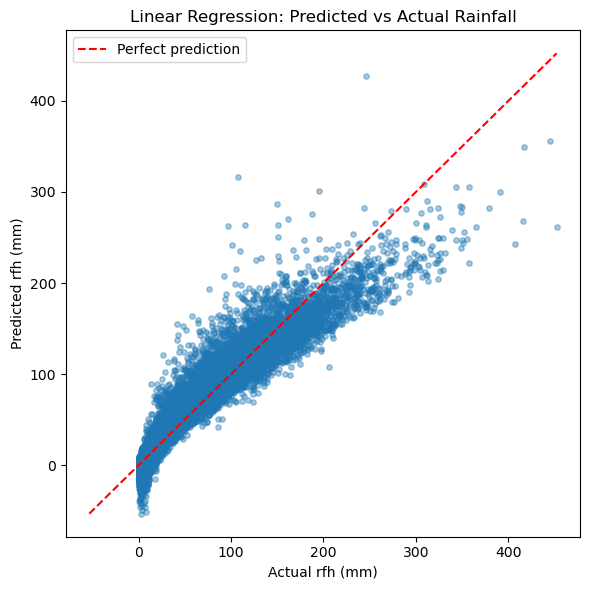

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, s=15)
lims = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual rfh (mm)')
plt.ylabel('Predicted rfh (mm)')
plt.title('Linear Regression: Predicted vs Actual Rainfall')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/linear_regression_pred_vs_actual.png', dpi=150)
plt.show()

## Residual plot

Checks whether errors are randomly scattered around zero (good fit) or
show a pattern/funnel shape (means the model is missing some non-linear
structure in the data).


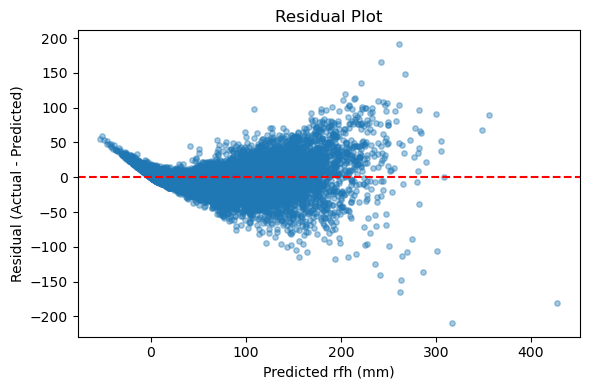

In [9]:
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_reg, residuals, alpha=0.4, s=15)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted rfh (mm)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('../outputs/linear_regression_residuals.png', dpi=150)
plt.show()

## Save results

Feeds into Utsab's master comparison table for Results & Evaluation.


In [10]:
results = pd.DataFrame([{
    'Model': 'Linear Regression',
    'RMSE': round(rmse, 3),
    'MAE': round(mae, 3),
    'R2': round(r2, 3)
}])
results.to_csv('../outputs/linear_regression_results.csv', index=False)
results

,Model,RMSE,MAE,R2
0,Linear Regression,15.461,8.836,0.92
